In [2]:
import pandas as pd
import numpy as np


Step 2

In [ ]:
# 2.1
df = pd.read_excel('credit_dataset.xls', header=1)
print(df.shape[0])

30000


In [ ]:
# 2.2
print(df.shape[1]-1)

# answer is 24 excluding outcome

24


2.3

Sex - Equal Credit Opportunity Act (ECOA) / Regulation B; also Title VII framing for sex discrimination
Age - ECOA (age is a prohibited basis in credit); ADEA is the usual employment-age statute if you want a parallel
Marriage ( Marital status) - ECOA (marital status is an explicit prohibited basis; FAQ allows it here)



Step 3

3.1 

Dataset outcome = Y

In [14]:
# 3.2 Creditworthiness formula
# Start at 100; deduct 10 points per month of delay across PAY_0, PAY_2..PAY_6.
# Only positive PAY values count as delay (-2, -1, 0 do not). Clip at 0.
# score = max(0, 100 - 10 * sum(max(PAY_i, 0)))

pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
delay_months = df[pay_cols].clip(lower=0).sum(axis=1)
df['creditworthiness'] = (100 - 10 * delay_months).clip(lower=0)

# sanity check: ID 1 should be 60 (delays 2+2=4 → 100-40)
print(df.loc[df['ID'] == 1, ['ID'] + pay_cols + ['creditworthiness']])
print(df['creditworthiness'].describe())

   ID  PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  creditworthiness
0   1      2      2     -1     -1     -2     -2                60
count    30000.000000
mean        85.055667
std         28.064981
min          0.000000
25%         80.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: creditworthiness, dtype: float64


3.3

protected class attribute = age

3.4 

Unprivileged: older (age ≥ 40)
Privileged: younger (age < 40)

In [15]:
# 3.5
train_df = df.sample(frac=0.5, random_state=42)
# drop the target for test data
test_df = df.drop(train_df.index)

# Report privileged/unprivileged counts in train and test.
for name, split in [('train', train_df), ('test', test_df)]:
    priv = (split['AGE'] < 40).sum()
    unpriv = (split['AGE'] >= 40).sum()
    print(f'{name}: privileged (young)={priv}, unprivileged (old)={unpriv}, n={len(split)}')

train: privileged (young)=10467, unprivileged (old)=4533, n=15000
test: privileged (young)=10389, unprivileged (old)=4611, n=15000


Step 4

* This is where i implement the 65 threshold.

<Axes: >

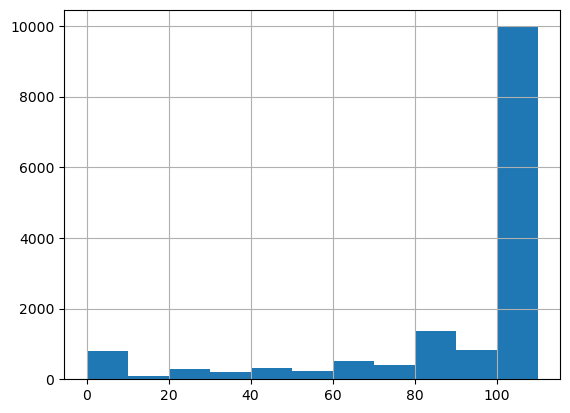

In [ ]:
# 4.1
#  There is 15000 customers in the training data
train_df['creditworthiness'].hist(bins=range(0, 111, 10))

In [18]:
# 4.2

y = train_df['default payment next month']  # 0=approved(good), 1=denied(bad)
score = train_df['creditworthiness']

def profit_for_threshold(x):
    approve = score >= x
    true_approve = (y == 0)
    p = np.where(true_approve & approve, 10,
        np.where(true_approve & ~approve, -5,
        np.where(~true_approve & approve, -10, 0)))
    return p.sum()

thresholds = range(10, 101, 5) #from score 10 too 100 with increament of 5
profits = {x: profit_for_threshold(x) for x in thresholds}
best_x = max(profits, key=profits.get)
print(profits)
print('best threshold', best_x, 'max profit', profits[best_x])

{10: 86190, 15: 86020, 20: 86020, 25: 86335, 30: 86335, 35: 85600, 40: 85600, 45: 85530, 50: 85530, 55: 84425, 60: 84425, 65: 82095, 70: 82095, 75: 79205, 80: 79205, 85: 69485, 90: 69485, 95: 62385, 100: 62385}
best threshold 25 max profit 86335


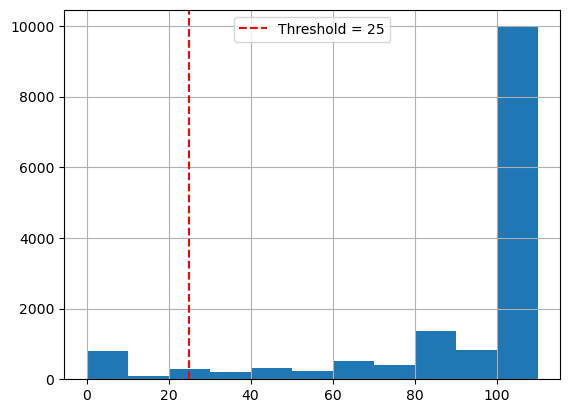

In [20]:
# 4.3

ax = train_df['creditworthiness'].hist(bins=range(0, 111, 10))
ax.axvline(25, color='red', linestyle='--', label='Threshold = 25')
ax.legend()

In [22]:
# 4.4

threshold = 25
train = train_df.copy()
train['outcome'] = np.where(
    train['creditworthiness'] >= threshold, 'Favorable (Approved)', 'Unfavorable (Declined)'
)
train['group'] = np.where(train['AGE'] < 40, 'Privileged (Young)', 'Unprivileged (Old)')
table = pd.crosstab(train['outcome'], train['group'])
# put Unfavorable row first to match FAQ table layout
table = table.reindex(['Unfavorable (Declined)', 'Favorable (Approved)'])
print(table)

group                   Privileged (Young)  Unprivileged (Old)
outcome                                                       
Unfavorable (Declined)                 815                 366
Favorable (Approved)                  9652                4167


Analysis, not much age bias noticed. That’s expected with threshold 25: almost everyone is approved. Disparate Impact would be about (0.919/0.922 ≈ 1.0) (near ideal)

Old has fewer approvals mainly because there are fewer older people in the train set — not because the threshold treats them differently.

Step 5

In [24]:
# 5.1 Fairness metrics on training set (threshold = 25)
# Demographic Parity / Disparate Impact: compare approval rates
# Equal Opportunity: compare TPR among truly good applicants (Y == 0)

threshold = 25
train = train_df.copy()
train['approved'] = train['creditworthiness'] >= threshold
train['privileged'] = train['AGE'] < 40  # young = privileged
y_good = train['default payment next month'] == 0  # Y=0 means no default / "should approve"

priv = train['privileged'] # where 'privileged' is true
unpriv = ~priv # flips it so where 'privileged' is false

# --- Demographic Parity ---
# approval rate = P(approved | group)
ar_priv = train.loc[priv, 'approved'].mean()
ar_unpriv = train.loc[unpriv, 'approved'].mean()
dp_diff = ar_unpriv - ar_priv                    # difference (unprivileged - privileged)
disparate_impact = ar_unpriv / ar_priv            # ratio form (handout example); ideal = 1.0

# --- Equal Opportunity ---
# TPR = P(approved | Y=0, group)  among people who truly deserved approval
tpr_priv = train.loc[priv & y_good, 'approved'].mean()
tpr_unpriv = train.loc[unpriv & y_good, 'approved'].mean()
eo_diff = tpr_unpriv - tpr_priv

print('Demographic Parity')
print(f'  approval rate privileged (young):   {ar_priv:.4f}')
print(f'  approval rate unprivileged (old):   {ar_unpriv:.4f}')
print(f'  difference (unpriv - priv):         {dp_diff:.4f}')
print(f'  Disparate Impact (unpriv/priv):     {disparate_impact:.4f}  (ideal 1.0; fair ~0.8-1.25)')
print()
print('Equal Opportunity')
print(f'  TPR privileged (young | Y=0):       {tpr_priv:.4f}')
print(f'  TPR unprivileged (old | Y=0):       {tpr_unpriv:.4f}')
print(f'  difference (unpriv - priv):         {eo_diff:.4f}  (ideal 0)')


Demographic Parity
  approval rate privileged (young):   0.9221
  approval rate unprivileged (old):   0.9193
  difference (unpriv - priv):         -0.0029
  Disparate Impact (unpriv/priv):     0.9969  (ideal 1.0; fair ~0.8-1.25)

Equal Opportunity
  TPR privileged (young | Y=0):       0.9653
  TPR unprivileged (old | Y=0):       0.9675
  difference (unpriv - priv):         0.0022  (ideal 0)


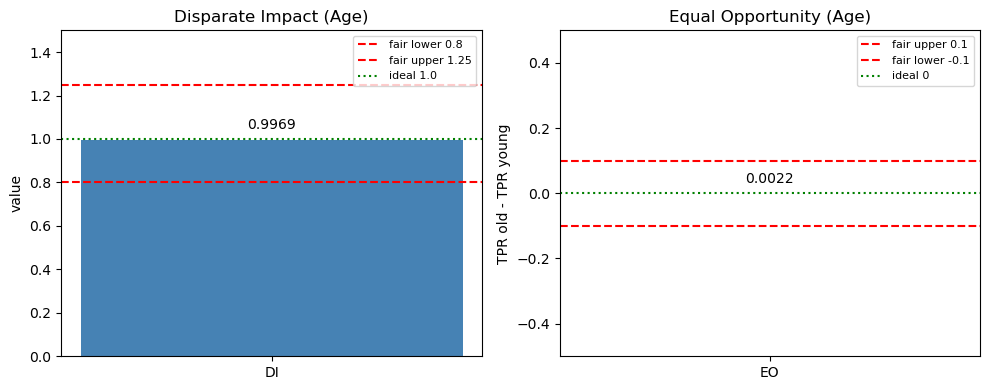

In [28]:
# 5.2 Plot fairness metrics with fair/bias thresholds
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Disparate Impact
axes[0].bar(['DI'], [disparate_impact], color='steelblue')
axes[0].axhline(0.8, color='red', linestyle='--', label='fair lower 0.8')
axes[0].axhline(1.25, color='red', linestyle='--', label='fair upper 1.25')
axes[0].axhline(1.0, color='green', linestyle=':', label='ideal 1.0')
axes[0].set_ylim(0, 1.5)
axes[0].set_title('Disparate Impact (Age)')
axes[0].set_ylabel('value')
axes[0].text(0, disparate_impact + 0.05, round(disparate_impact, 4), ha='center')
axes[0].legend(fontsize=8)

# Equal Opportunity difference
axes[1].bar(['EO'], [eo_diff], color='steelblue')
axes[1].axhline(0.1, color='red', linestyle='--', label='fair upper 0.1')
axes[1].axhline(-0.1, color='red', linestyle='--', label='fair lower -0.1')
axes[1].axhline(0, color='green', linestyle=':', label='ideal 0')
axes[1].set_ylim(-0.5, 0.5)
axes[1].set_title('Equal Opportunity (Age)')
axes[1].set_ylabel('TPR old - TPR young')
axes[1].text(0, eo_diff + 0.03, round(eo_diff, 4), ha='center')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# 5.3 Document fairness metrics (simple table for the report)
from IPython.display import display, HTML

summary_5_3 = pd.DataFrame([
    {
        'Fairness metric': 'Disparate Impact',
        'Computed value': round(disparate_impact, 4),
        'Acceptable range': '0.8 to 1.25 (ideal 1.0)',
        'Bias?': 'No' if 0.8 <= disparate_impact <= 1.25 else 'Yes',
    },
    {
        'Fairness metric': 'Equal Opportunity',
        'Computed value': round(eo_diff, 4),
        'Acceptable range': '-0.1 to 0.1 (ideal 0)',
        'Bias?': 'No' if abs(eo_diff) <= 0.1 else 'Yes',
    },
])

display(HTML(summary_5_3.to_html(index=False, border=1)))


Fairness metric,Computed value,Acceptable range,Bias?
Disparate Impact (Demographic Parity),0.9969,0.8 to 1.25 (ideal 1.0),No
Equal Opportunity (TPR difference),0.0022,-0.1 to 0.1 (ideal 0),No


References

5.3
- https://www.eeoc.gov/laws/guidance/questions-and-answers-clarify-and-provide-common-interpretation-uniform-guidelines
- https://link.springer.com/article/10.1007/s43681-024-00541-3